# Finding Counterexamples

## Code

In [ ]:
import matplotlib.pyplot as plt
import torch


In [ ]:

def exp_power_kernel(X, Y, ell, beta=0.01):
    """
    Compute the kernel
        k_ell(x,y) = exp( - (||x-y||/ell)^beta )
    in a vectorized manner.
    
    Parameters:
      X: torch.Tensor of shape [n, d] -- n points in d dimensions.
      Y: torch.Tensor of shape [m, d] -- m points in d dimensions.
      ell: positive scalar, the lengthscale parameter.
      beta: positive scalar exponent.
      
    Returns:
      K: torch.Tensor of shape [n, m] with entries 
         K[i,j] = exp( - (||X[i]-Y[j]||/ell)^beta ).
    """
    # Compute pairwise differences: shape [n, m, d]
    diff = X.unsqueeze(1) - Y.unsqueeze(0)
    # Compute the Euclidean distance between points.
    # Add a tiny constant to avoid division by zero.
    r = torch.sqrt(torch.sum(diff**2, dim=2) + 1e-12)
    # Compute the kernel: note that (r/ell)^beta = r^beta / ell^beta.
    K = torch.exp( - (r / ell) ** beta )
    return K

def d_exp_power_kernel_dell(X, Y, ell, beta=0.01):
    """
    Compute the derivative of the kernel
        k_ell(x,y) = exp( - (||x-y||/ell)^beta )
    with respect to the lengthscale ell, i.e.,
    
        ∂_ell k_ell(x,y) = [β/ell^(β+1)] ||x-y||^β k_ell(x,y).
    
    Parameters:
      X: torch.Tensor of shape [n, d]
      Y: torch.Tensor of shape [m, d]
      ell: positive scalar, the lengthscale parameter.
      beta: positive scalar exponent.
      
    Returns:
      dK: torch.Tensor of shape [n, m] containing the derivative of the kernel 
          with respect to ell.
    """
    diff = X.unsqueeze(1) - Y.unsqueeze(0)
    r = torch.sqrt(torch.sum(diff**2, dim=2) + 1e-12)
    K = torch.exp( - (r / ell) ** beta )
    dK = (beta * r**beta / (ell**(beta + 1))) * K
    return dK


In [ ]:

def matern12(X, Y, ell, sigma):
    """
    Compute the Matern 1/2 (exponential) kernel between each row of X and Y.
    
    Parameters:
      X: Tensor of shape [n, d]
      Y: Tensor of shape [m, d]
      ell: lengthscale (scalar)
      sigma: amplitude (scalar)
      
    Returns:
      K: Tensor of shape [n, m] containing the covariance between points in X and Y.
    """
    # Compute pairwise differences: shape [n, m, d]
    diff = X.unsqueeze(1) - Y.unsqueeze(0)
    # Compute Euclidean distance (with a small term added for numerical stability)
    r = torch.sqrt(torch.sum(diff ** 2, dim=2) + 1e-12)
    # Exponential kernel (Matern 1/2)
    K = sigma**2 * torch.exp(-r / ell)
    return K

def d_matern12_dell(X, Y, ell, sigma):
    """
    Compute the derivative of the Matern 1/2 (exponential) kernel with respect to the lengthscale ell.
    
    Parameters:
      X: Tensor of shape [n, d]
      Y: Tensor of shape [m, d]
      ell: lengthscale (scalar)
      sigma: amplitude (scalar)
      
    Returns:
      dK: Tensor of shape [n, m] containing the derivative of the covariance with respect to ell.
    """
    # Compute pairwise differences: shape [n, m, d]
    diff = X.unsqueeze(1) - Y.unsqueeze(0)
    # Compute Euclidean distances
    r = torch.sqrt(torch.sum(diff ** 2, dim=2) + 1e-12)
    # Derivative with respect to ell:
    # d/dell exp(-r/ell) = exp(-r/ell) * (r / ell^2)
    dK = sigma**2 * torch.exp(-r / ell) * (r / (ell**2))
    return dK


In [ ]:

def periodic_kernel(X, Y, ell, sigma, p=1.):
    """
    Compute the periodic kernel between each row of X and Y.
    
    The kernel is defined as:
    
      k_ell(x, y) = sigma^2 * exp( - (2/p^2) * sin^2( pi * ||x-y|| / ell ) )
    
    Parameters:
      X: Tensor of shape [n, d]
      Y: Tensor of shape [m, d]
      ell: lengthscale (scalar) controlling the scaling of the difference between x and y.
      sigma: amplitude (scalar)
      p: period parameter (scalar) controlling the periodic structure
      
    Returns:
      K: Tensor of shape [n, m] containing the covariance between points in X and Y.
    """
    # Compute pairwise differences: shape [n, m, d]
    diff = X.unsqueeze(1) - Y.unsqueeze(0)
    # Euclidean distance (with a tiny constant added for numerical stability)
    r = torch.sum(diff**2, dim=2)
    # Compute the sine squared term: sin^2( pi*r / ell )
    A = torch.sin(torch.pi * r / ell) ** 2
    # Compute the kernel
    K = sigma**2 * torch.exp(-2 * A / (p**2))
    return K

def d_periodic_kernel_dell(X, Y, ell, sigma, p=1.):
    """
    Compute the derivative of the periodic kernel with respect to the lengthscale ell.
    
    For the kernel:
    
      k_ell(x,y) = sigma^2 * exp( - (2/p^2) * sin^2( pi * ||x-y|| / ell ) )
    
    we have (using the chain rule):
    
      d/dell k_ell(x,y) = k_ell(x,y) * (2πr/(p^2 ell^2)) * sin(2πr/ell)
    
    where r = ||x-y||.
    
    Parameters:
      X: Tensor of shape [n, d]
      Y: Tensor of shape [m, d]
      ell: lengthscale (scalar)
      sigma: amplitude (scalar)
      p: period parameter (scalar)
      
    Returns:
      dK: Tensor of shape [n, m] containing the derivative of k_ell with respect to ell.
    """
    # Compute pairwise differences and Euclidean distance.
    diff = X.unsqueeze(1) - Y.unsqueeze(0)
    r = torch.sqrt(torch.sum(diff**2, dim=2) + 1e-12)
    
    # Compute the sine squared term used in the kernel.
    A = torch.sin(torch.pi * r / ell) ** 2
    # Compute the kernel.
    K = sigma**2 * torch.exp(-2 * A / (p**2))
    
    # Compute derivative of sin^2(pi*r/ell) with respect to ell.
    # Let v = pi*r/ell, so that sin^2(v)' = 2 sin(v) cos(v) * (-pi*r/ell^2)
    # That is, d/dell sin^2(pi*r/ell) = - (pi*r/ell^2) sin(2pi*r/ell).
    #
    # Then by the chain rule:
    #   d/dell k_ell(x,y) = k_ell(x,y) * (-2/p^2) * (d/dell sin^2(pi*r/ell))
    #                     = k_ell(x,y) * (-2/p^2) * ( - (pi*r/ell^2)* sin(2pi*r/ell) )
    #                     = k_ell(x,y) * (2*pi*r/(p^2 * ell^2)) * sin(2pi*r/ell).
    
    dK = K * (2 * torch.pi * r * torch.sin(2 * torch.pi * r / ell)) / (p**2 * ell**2)
    return dK


In [ ]:
def kernel_exp(X, Y, ell, sigma):
    """
    Compute the kernel 
      k_ell(x,y) = exp(exp(-||x-y||^2/ell^2) - 1)
    between each row of X and Y, using the squared Euclidean distance.
    
    Args:
        X: torch.Tensor of shape [n, d]
        Y: torch.Tensor of shape [m, d]
        ell: scalar (or a 0-d torch.Tensor) representing the lengthscale
        sigma: scalar, the overall scale parameter
    
    Returns:
        K: torch.Tensor of shape [n, m]
    """
    # Compute pairwise differences.
    # X: [n, d], Y: [m, d] -> diff: [n, m, d]
    diff = X.unsqueeze(1) - Y.unsqueeze(0)
    
    # Compute squared Euclidean distances: r2 = ||x-y||^2.
    r2 = torch.sum(diff ** 2, dim=2)
    
    # Compute k_ell(x,y) = exp(exp(-r2/ell^2) - 1)
    K = torch.exp(torch.exp(-r2 / ell**2) - 1)
    return sigma ** 2 * K

def d_kernel_exp_dell(X, Y, ell, sigma):
    """
    Compute the derivative of the kernel 
      k_ell(x,y) = exp(exp(-||x-y||^2/ell^2) - 1)
    with respect to the lengthscale ell.
    
    The derivative is given by:
      d/dell k_ell(x,y) = 2 * k_ell(x,y) * (r2/ell^3) * exp(-r2/ell^2),
    where r2 = ||x-y||^2.
    
    Args:
        X: torch.Tensor of shape [n, d]
        Y: torch.Tensor of shape [m, d]
        ell: scalar (or a 0-d torch.Tensor) representing the lengthscale
        sigma: scalar, the overall scale parameter
    
    Returns:
        dK: torch.Tensor of shape [n, m]
    """
    # Compute pairwise differences.
    diff = X.unsqueeze(1) - Y.unsqueeze(0)
    
    # Compute squared Euclidean distances.
    r2 = torch.sum(diff ** 2, dim=2)
    
    # Compute the kernel.
    K = torch.exp(torch.exp(-r2 / ell**2) - 1)
    
    # Compute the derivative: dK = 2*K*(r2/ell^3)*exp(-r2/ell^2)
    dK = 2 * K * (r2 / (ell ** 3)) * torch.exp(-r2 / ell**2)
    return sigma ** 2 * dK


In [ ]:

def matern32(X, Y, ell, sigma):
    """
    Compute the Matern 3/2 kernel between each row of X and Y.
    X: tensor of shape [n, d]
    Y: tensor of shape [m, d]
    ell: lengthscale (scalar)
    sigma: amplitude (scalar)
    Returns:
      K: tensor of shape [n, m]
    """
    # Compute pairwise differences and Euclidean distances
    # X: [n,d], Y: [m,d] --> diff: [n, m, d]
    diff = X.unsqueeze(1) - Y.unsqueeze(0)
    # Add a small number for numerical stability
    r = torch.sqrt(torch.sum(diff ** 2, dim=2) + 1e-12)
    sqrt3 = torch.sqrt(torch.tensor(3.0, device=X.device))
    z = sqrt3 * r / ell
    K = sigma**2 * (1.0 + z) * torch.exp(-z)
    return K

def d_matern32_dell(X, Y, ell, sigma):
    """
    Compute the derivative of the Matern 3/2 kernel with respect to ell.
    X: tensor of shape [n, d]
    Y: tensor of shape [m, d]
    Returns:
      dK: tensor of shape [n, m]
    """
    diff = X.unsqueeze(1) - Y.unsqueeze(0)
    r = torch.sqrt(torch.sum(diff ** 2, dim=2) + 1e-12)
    sqrt3 = torch.sqrt(torch.tensor(3.0, device=X.device))
    z = sqrt3 * r / ell
    dK = sigma**2 * ( (sqrt3 * r / ell)**2 / ell ) * torch.exp(-z)
    # which is equivalent to sigma^2 * (3 * r^2)/(ell^3) * exp(-z)
    return dK

def g_prime(X, ell, sigma, lambd, kernel=matern12, dkernel=d_matern12_dell):
    """
    Compute the derivative g'(ell) with respect to the kernel hyperparameter ell.
    X: tensor of shape [n, d]
    ell: lengthscale (scalar)
    sigma: amplitude (scalar)
    lambd: regularization parameter (scalar)
    
    Returns:
      gp: scalar (the value of g'(ell))
    """
    n = X.shape[0]
    device = X.device
    # Define 0 in R^d
    zero = torch.zeros(1, X.shape[1], device=device)
    
    # Compute k(0, X) and its derivative: shape [1, n]
    k0 = kernel(zero, X, ell, sigma)         # [1, n]
    dk0 = dkernel(zero, X, ell, sigma)   # [1, n]
    
    # Compute K = k(X,X) and its derivative: shape [n, n]
    K = kernel(X, X, ell, sigma)
    dK = dkernel(X, X, ell, sigma)
    
    # Regularize the kernel matrix
    K_reg = K + lambd * torch.eye(n, device=device)
    
    # Solve for alpha:  K_reg * alpha = k0^T
    alpha = torch.linalg.solve(K_reg, k0.t())  # shape [n, 1]
    
    # Compute g'(ell) = 2*(dk0 @ alpha) - alpha^T @ dK @ alpha.
    term1 = 2 * (dk0 @ alpha)       # shape [1, 1]
    term2 = (alpha.t() @ dK @ alpha)  # shape [1, 1]
    gp = term1 - term2
    return gp.squeeze()  # return a scalar


In [ ]:
def optimize_X(initial_X, ell, sigma, lambd,
               r_target=1.0, reg_coef_target=1.0,
               reg_coef_repulsion=1.0, gamma=1.0,
               lr=1e-3, n_iters=1000,
               kernel=matern12, dkernel=d_matern12_dell):
    """
    Optimize the data points X (of shape [n,d]) to minimize g'(ell) with additional penalties:
      - A target penalty to keep the average distance from the origin near r_target.
      - A repulsion penalty to discourage points from getting too close to each other.
    
    Parameters:
      initial_X: initial tensor for X (shape [n, d])
      ell: kernel lengthscale (scalar)
      sigma: kernel amplitude (scalar)
      lambd: regularization parameter for the kernel matrix inversion
      r_target: desired average distance from the origin (scalar)
      reg_coef_target: coefficient for the target average distance penalty
      reg_coef_repulsion: coefficient for the repulsion penalty
      gamma: width parameter for the repulsion penalty
      lr: learning rate for the optimizer
      n_iters: number of optimization iterations
      kernel: function to compute the kernel (default: matern12)
      dkernel: function to compute the derivative of the kernel w.r.t. ell (default: d_matern12_dell)
    
    Returns:
      X: optimized tensor of shape [n, d]
    """
    X = initial_X.clone().detach().requires_grad_(True)
    optimizer = torch.optim.Adam([X], lr=lr)
    
    for i in range(n_iters):
        optimizer.zero_grad()
        
        # Compute the original objective derivative g'(ell)
        gp = g_prime(X, ell, sigma, lambd, kernel=kernel, dkernel=dkernel)
        
        # Penalty to encourage the average distance from the origin to be close to r_target
        target_pen = target_distance_penalty(X, r_target, reg_coef_target)
        
        # Repulsion penalty to discourage points from being too close
        repulsion_loss = reg_coef_repulsion * repulsion_penalty(X, gamma=gamma)
        
        # Total loss combines the original objective and the penalties.
        loss = gp + target_pen + repulsion_loss
        loss.backward()
        optimizer.step()
        
        if i % 100 == 0:
            print(f"Iter {i}: loss = {loss.item():.4f}, gp = {gp.item():.4f}, "
                  f"target_penalty = {target_pen.item():.4f}, repulsion = {repulsion_loss.item():.4f}")
    
    return X


In [ ]:
def repulsion_penalty(X, gamma=1.0):
    """
    Compute a repulsion penalty to discourage points from being too close.
    
    Parameters:
      X: Tensor of shape [n, d]
      gamma: controls the width of the repulsion (scalar)
      
    Returns:
      repulsion: a scalar tensor that is large if many pairs of points are very close.
    """
    # Compute pairwise differences: shape [n, n, d]
    diff = X.unsqueeze(1) - X.unsqueeze(0)
    # Compute squared Euclidean distances: shape [n, n]
    sq_dist = torch.sum(diff ** 2, dim=2)
    
    # Create an upper-triangular mask to avoid double-counting and ignore self-distances.
    n = X.shape[0]
    mask = torch.triu(torch.ones(n, n, device=X.device), diagonal=1)
    
    # Compute the repulsion penalty:
    # For pairs (i,j), if they are too close (small sq_dist), exp(-sq_dist/(2*gamma^2)) is near 1.
    repulsion = torch.sum(torch.exp(-sq_dist / (2 * gamma**2)) * mask)
    
    return repulsion

def target_distance_penalty(X, r_target, reg_coef_target=1.0):
    """
    Compute a penalty to encourage the average distance from the origin to be near r_target.
    
    Parameters:
      X: Tensor of shape [n, d]
      r_target: desired average distance from the origin (scalar)
      reg_coef_target: regularization coefficient for this penalty
      
    Returns:
      penalty: scalar tensor
    """
    # Compute the Euclidean norm of each point.
    distances = torch.norm(X, dim=1)
    avg_distance = torch.mean(distances)
    penalty = reg_coef_target * (avg_distance - r_target)**2
    return penalty


In [ ]:
def plot_g_prime(ells, X, sigma, lambd, kernel=kernel_exp, dkernel=d_kernel_exp_dell):
    g_primes = []
    for i in ells:
        g_primes.append(g_prime(X, i, sigma, lambd, kernel=kernel, dkernel=dkernel))

    ys = torch.stack(g_primes).detach()

    plt.plot(ells, ys)
    plt.xlabel('$\ell$')
    plt.ylabel('$g\'(\ell)$')


### Optimisation

In [ ]:
X = torch.randn(100,2) * 0.01

ell = 1e-4
sigma = 1.
lambd = 1

optimal_X = optimize_X(X, ell, sigma, lambd,
               reg_coef_target=1e-9, reg_coef_repulsion=1e-9, gamma=1.,
               lr=1e-3, n_iters=1,
               kernel=kernel_exp, dkernel=d_kernel_exp_dell)



In [ ]:
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (3,3)

x_detach = optimal_X.detach()

plt.scatter(X.T[0], X.T[1], zorder=2, alpha=1)
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
# plt.title('Using $\ell = 10^{-4}$')
# plt.scatter(X.T[0], X.T[1], alpha=1, zorder=1, color='green', marker='x')

# for i in range(x_detach.shape[0]):
#     plt.plot([X[i][0], x_detach[i][0]], [X[i][1], x_detach[i][1]], zorder=0, color='red')

In [ ]:
X = torch.randn(30,2) * 0.01
X[0] += 10

$$ f(x,y | \mu) = f(y|x, \mu) f(x|\mu) $$

In [ ]:
X = torch.randn(4,2) * 0.01
X[0] += 1000

plt.rcParams["figure.figsize"] = (4,3)

lambd = 1e2

ells = torch.linspace(1e-12,  1.1 * 1e-1, 100)

plot_g_prime(ells, X, sigma=sigma, lambd=lambd, kernel=matern32, dkernel=d_matern32_dell)

In [ ]:
plt.scatter(X.T[0], X.T[1], zorder=2, alpha=1)


In [ ]:
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (8,8)

x_detach = optimal_X.detach()

plt.scatter(x_detach.T[0], torch.zeros_like(x_detach.T[0]), zorder=2, alpha=1)
plt.scatter(X.T[0], torch.zeros_like(x_detach.T[0]), zorder=1, color='green', marker='x')

# plt.scatter(X.T[0], X.T[1], alpha=1, zorder=1, color='green', marker='x')

# for i in range(x_detach.shape[0]):
#     plt.plot([X[i][0], x_detach[i][0]], [X[i][1], x_detach[i][1]], zorder=0, color='red')

In [ ]:
X = torch.randn(50,2) * 5

ell = 0.5
sigma = 1.
lambd = 1e-4

optimal_X = optimize_X(X, ell, sigma, lambd,
               reg_coef_target=1e-5, reg_coef_repulsion=1e-2, gamma=1.,
               lr=1e-3, n_iters=20000,
               kernel=exp_power_kernel, dkernel=d_exp_power_kernel_dell)



In [ ]:
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (8,8)

x_detach = optimal_X.detach()

plt.scatter(x_detach.T[0], x_detach.T[1], zorder=2, alpha=1)
plt.scatter(X.T[0], X.T[1], alpha=1, zorder=1, color='green', marker='x')

for i in range(x_detach.shape[0]):
    plt.plot([X[i][0], x_detach[i][0]], [X[i][1], x_detach[i][1]], zorder=0, color='red')

In [ ]:

Y = x_detach.numpy()

out1, separate_terms = compute_integrand2(s, Y, ell=ell, lambd=lambd, kernel=matern32_kernel)

print(out1.sum() * (b / n_s))
# plt.plot(s, s * separate_terms[0] , label='term1')
# plt.plot(s, separate_terms[1] + separate_terms[2], label = 'term2')
# plt.plot(s, , label = 'term3')
plt.plot(s, out1, label = 'term3')
plt.xlabel('$s$')
plt.ylabel('$h(s)$')
plt.axhline(0, color='k', linestyle='--')
# plt.scatter([1],[0], zorder=2)

plt.legend()

In [ ]:
g_prime(x_detach/100, ell, 1., 1e-9)

In [ ]:
g_prime(x_detach, 1., 1., 1e-9)

In [ ]:
ells = torch.linspace(0.01, 0.1, 2000)

gs2 = []

for i in ells:
    gs2.append(g_prime(x_detach, i, 1., 1e-4, kernel=periodic_kernel, dkernel=d_periodic_kernel_dell))


plt.plot(ells,torch.stack(gs2))

In [ ]:
torch.stack(gs2)

# Screening Effect

In [81]:
import torch
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (3,3)

def matern32(X, Y, ell, sigma):
    """
    Compute the Matern 3/2 kernel between each row of X and Y.
    X: tensor of shape [n, d]
    Y: tensor of shape [m, d]
    ell: lengthscale (scalar)
    sigma: amplitude (scalar)
    Returns:
      K: tensor of shape [n, m]
    """
    # Compute pairwise differences and Euclidean distances
    diff = X.unsqueeze(1) - Y.unsqueeze(0)  # [n, m, d]
    r = torch.sqrt(torch.sum(diff ** 2, dim=2) + 1e-12)
    sqrt3 = torch.sqrt(torch.tensor(3.0, device=X.device))
    z = sqrt3 * r / ell
    K = sigma**2 * (1.0 + z) * torch.exp(-z)
    return K

def kernel_exp(X, Y, ell, sigma):
    """
    Compute the kernel 
      k_ell(x,y) = exp(exp(-||x-y||^2/ell^2) - 1)
    between each row of X and Y, using the squared Euclidean distance.
    
    Args:
        X: torch.Tensor of shape [n, d]
        Y: torch.Tensor of shape [m, d]
        ell: scalar (or a 0-d torch.Tensor) representing the lengthscale
        sigma: scalar, the overall scale parameter
    
    Returns:
        K: torch.Tensor of shape [n, m]
    """
    # Compute pairwise differences.
    # X: [n, d], Y: [m, d] -> diff: [n, m, d]
    diff = X.unsqueeze(1) - Y.unsqueeze(0)
    
    # Compute squared Euclidean distances: r2 = ||x-y||^2.
    r2 = torch.sum(diff ** 2, dim=2)
    
    # Compute k_ell(x,y) = exp(exp(-r2/ell^2) - 1)
    K = torch.exp(torch.exp(-r2 / ell**2) - 1)
    return sigma ** 2 * K

def compute_v(r, X, ell, sigma, lambd, kernel=kernel_exp):
    """
    Compute v(r; lambda) = k_r(0,0) - a(r) [k_r(X,X) + lambda I]^{-1} a(r)^T.
    
    Arguments:
      r: scalar (float or 0-dim tensor) scaling factor.
      X: tensor of shape [n, d] representing the input locations.
      ell: kernel lengthscale.
      sigma: kernel amplitude.
      lambd: regularization parameter.
      kernel: function implementing the kernel (default is matern32).
    
    Returns:
      v: a scalar tensor representing v(r; lambda).
    """
    device = X.device
    d = X.shape[1]
    # Define 0 in R^d.
    zero = torch.zeros(1, d, device=device)
    
    # Compute scaled versions of X.
    X_scaled = r * X
    zero_scaled = r * zero  # remains zero, but formally
    
    # k_r(0,0)
    k00 = kernel(zero_scaled, zero_scaled, ell, sigma)  # shape [1,1]
    
    # a(r) = k_r(0, X) = k(0, r*X)
    a = kernel(zero_scaled, X_scaled, ell, sigma)  # shape [1, n]
    
    # A(r) = k_r(X, X) + lambda I
    A = kernel(X_scaled, X_scaled, ell, sigma) + lambd * torch.eye(X.shape[0], device=device)
    
    # Solve A^{-1} a^T using torch.linalg.solve
    # a^T: shape [n, 1]
    aT = a.t()
    A_inv_aT = torch.linalg.solve(A, aT)  # shape [n, 1]
    
    # Compute quadratic form: a A^{-1} a^T, a: [1, n] and A_inv_aT: [n,1]
    quad = torch.matmul(a, A_inv_aT)  # shape [1,1]
    
    v = k00 - quad  # shape [1,1]
    return v.squeeze()  # return as a scalar

def compute_v_star(r, X, X_star, ell, sigma, lambd, kernel=kernel_exp):
    """
    Compute v^*(r; lambda) using the modified kernel:
      k^*_r(x,y) = k(r x, r y, ell, sigma) 
                   - k(r x, X_star, ell, sigma) [k(X_star, X_star, ell, sigma) + lambda I]^{-1} k(X_star, r y, ell, sigma)
    
    Then, v^*(r; lambda) = k^*_r(0,0) - a^*(r)[k^*_r(X,X) + lambda I]^{-1}(a^*(r))^T,
    where a^*(r) = k^*_r(0, X).
    
    Arguments:
      r: scalar (float or 0-dim tensor) scaling factor.
      X: tensor of shape [n, d] (local data).
      X_star: tensor of shape [m, d] (distant data).
      ell: kernel lengthscale.
      sigma: kernel amplitude.
      lambd: regularization parameter.
      kernel: function implementing the kernel (default is matern32).
    
    Returns:
      v_star: a scalar tensor representing v^*(r; lambda).
    """
    device = X.device
    d = X.shape[1]
    # Define 0 in R^d.
    zero = torch.zeros(1, d, device=device)
    
    # Scale local inputs and the prediction point.
    X_scaled = r * X
    zero_scaled = r * zero  # remains zero
    # For the distant data, we do not scale:
    X_star = X_star  # remains unchanged
    
    # First, compute the base kernel on the scaled points.
    K_base = kernel  # shorthand
    
    # Compute k_r(0,0) = kernel(0,0) with scaled inputs.
    k00 = K_base(zero_scaled, zero_scaled, ell, sigma)  # shape [1,1]
    
    # Compute the cross-covariance between the prediction point and X_star.
    k0_Xstar = K_base(zero_scaled, X_star, ell, sigma)  # shape [1, m]
    # Compute the covariance among X_star.
    K_Xstar = K_base(X_star, X_star, ell, sigma)  # shape [m, m]
    
    # Regularize K_Xstar.
    K_Xstar_reg = K_Xstar + lambd * torch.eye(X_star.shape[0], device=device)
    
    # Solve for the adjustment term: we need to compute
    # Q = k0_Xstar [K_Xstar_reg]^{-1} k(X_star, 0),
    # where k(X_star, 0) = transpose of k0_Xstar.
    k_Xstar_0 = k0_Xstar.t()  # shape [m, 1]
    A_inv_k = torch.linalg.solve(K_Xstar_reg, k_Xstar_0)  # shape [m, 1]
    Q = torch.matmul(k0_Xstar, A_inv_k)  # shape [1,1]
    
    # The modified kernel at (0,0) is then
    k00_star = k00 - Q  # scalar
    
    # Now define the modified kernel function for any inputs:
    # k^*_r(x,y) = kernel(r*x, r*y, ell, sigma) - k(r*x, X_star, ell, sigma)[K_Xstar_reg]^{-1}k(X_star, r*y, ell, sigma)
    def k_star_r(x, y):
        # x and y are assumed to be 2D tensors (n_x x d) and (n_y x d), respectively.
        x_scaled = r * x
        y_scaled = r * y
        term1 = K_base(x_scaled, y_scaled, ell, sigma)
        term2_left = K_base(x_scaled, X_star, ell, sigma)  # shape: [n_x, m]
        term2_right = K_base(X_star, y_scaled, ell, sigma)  # shape: [m, n_y]
        # Solve: [K_Xstar_reg]^{-1} term2_right; here we solve for each column of term2_right.
        sol = torch.linalg.solve(K_Xstar_reg, term2_right)  # shape: [m, n_y]
        term2 = torch.matmul(term2_left, sol)  # shape: [n_x, n_y]
        return term1 - term2
    
    # print(k_star_r(torch.Tensor([[0,0]]), torch.Tensor([[0,0]])))


    # Now, we need to compute a^*(r) = k^*_r(0, X) and A^*(r) = k^*_r(X, X) + lambda I.
    a_star = k_star_r(zero_scaled, X)  # shape [1, n]
    A_star = k_star_r(X, X) + lambd * torch.eye(X.shape[0], device=device)  # shape [n, n]
    
    # Solve for A_star^{-1} a_star^T.
    a_star_T = a_star.t()  # shape [n, 1]
    A_star_inv_a = torch.linalg.solve(A_star, a_star_T)  # shape [n, 1]
    
    # Compute the quadratic form.
    quad_star = torch.matmul(a_star, A_star_inv_a)  # shape [1,1]
    
    # Finally, v^*(r; lambda) = k^*_r(0,0) - a_star A_star^{-1} a_star^T.
    v_star = k00_star - quad_star  # shape [1,1]
    
    return v_star.squeeze()  # return as a scalar



def k_star_r(x, y, X_star, r=1, kernel=kernel_exp, ell=ell, sigma=sigma, lambd=lambd):
  device = x.device
  # x and y are assumed to be 2D tensors (n_x x d) and (n_y x d), respectively.
  x_scaled = r * x
  y_scaled = r * y
  term1 = kernel(x_scaled, y_scaled, ell, sigma)
  term2_left = kernel(x_scaled, X_star, ell, sigma)  # shape: [n_x, m]
  term2_right = kernel(X_star, y_scaled, ell, sigma)  # shape: [m, n_y]

  K_Xstar = kernel(X_star, X_star, ell, sigma)  # shape [m, m]
  K_Xstar_reg = K_Xstar + lambd * torch.eye(X_star.shape[0], device=device)
  # Solve: [K_Xstar_reg]^{-1} term2_right; here we solve for each column of term2_right.
  sol = torch.linalg.solve(K_Xstar_reg, term2_right)  # shape: [m, n_y]
  term2 = torch.matmul(term2_left, sol)  # shape: [n_x, n_y]
  return term1 - term2

### Defining Hyperparameters

In [84]:
ell = 1
sigma = 1
lambd = 1e-4  # regularization


### Checking Ratio Converges

In [86]:
torch.manual_seed(0)

zeros = torch.Tensor([[0,0]])
X_star = torch.randn((3,2)) * 1


sigma_star_ = k_star_r(zeros, zeros, X_star, r=10)
sigma_ = kernel_exp(zeros, zeros, ell=ell, sigma=sigma)

sigma_star_

tensor([[0.7432]])

In [79]:
matern32(zeros, zeros, ell=ell, sigma=sigma)

tensor([[1.]])

In [88]:
torch.manual_seed(0)

# Define parameters.
ell = 1.0
sigma = 1.0
lambd = 1e-3  # regularization
r = 0.1  # scaling factor

# Create some synthetic data for local inputs X (say, 5 points in 1D) and distant data X_star (say, 3 points in 1D)
X = torch.randn((5,2))
X_star = torch.randn((3,2)) * 1

# Compute v(r; lambda)
v_val = compute_v(r, X, ell, sigma, lambd)
print("v(r; lambda) =", v_val.item())

# Compute v^*(r; lambda)
v_star_val = compute_v_star(r, X, X_star, ell, sigma, lambd)
print("v^*(r; lambda) =", v_star_val.item())


v(r; lambda) = 0.0007195472717285156
v^*(r; lambda) = 0.0006738901138305664


In [89]:
lambd = 1.  # regularization


compute_v_star(torch.Tensor([0]), X, X_star, ell, sigma, lambd) / compute_v(torch.Tensor([0]), X, ell, sigma, lambd)

tensor(0.9310)

In [13]:
compute_v(torch.Tensor([0]), X, ell, sigma, lambd)

tensor(0.0002)

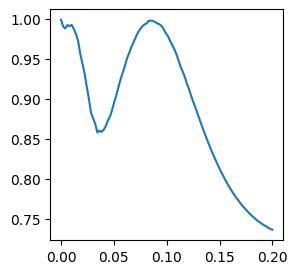

In [92]:
r = torch.linspace(0, 0.2, 100)
ell = 1
lambd = 1e-4  # regularization


v_vals = []
v_star_vals = []
for i in r:
    v_vals.append(compute_v(i, X, ell, sigma, lambd))
    v_star_vals.append(compute_v_star(i, X, X_star, ell, sigma, lambd))

v_ratio = torch.stack(v_star_vals) / torch.stack(v_vals)

plt.plot(r, v_ratio)
